In [4]:
!pip install albumentations -q

import os
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, roc_auc_score)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                      BatchNormalization, Conv2D, MaxPooling2D,
                                      Add, Activation, Input, ZeroPadding2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import albumentations as A
import kagglehub

# ── Training Dataset ───────────────────────────────
path_big = kagglehub.dataset_download("zaidpy/oral-cancer-dataset")
print(f"✅ Big dataset: {path_big}")

# ── Test Dataset ───────────────────────────────────
path_small = kagglehub.dataset_download(
    "shivam17299/oral-cancer-lips-and-tongue-images")
print(f"✅ Small dataset: {path_small}")

Using Colab cache for faster access to the 'oral-cancer-dataset' dataset.
✅ Big dataset: /kaggle/input/oral-cancer-dataset
Using Colab cache for faster access to the 'oral-cancer-lips-and-tongue-images' dataset.
✅ Small dataset: /kaggle/input/oral-cancer-lips-and-tongue-images


In [5]:
import kagglehub
path = kagglehub.dataset_download("zaidpy/oral-cancer-dataset")
print(path)  # Check version number

# Then see actual structure
import os
for root, dirs, files in os.walk(path):
    images = [f for f in files if f.lower().endswith(('.jpg','.png','.jpeg'))]
    if images:
        print(f"{root}  →  {len(images)} images")

Using Colab cache for faster access to the 'oral-cancer-dataset' dataset.
/kaggle/input/oral-cancer-dataset
/kaggle/input/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER  →  500 images
/kaggle/input/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/NON CANCER  →  250 images
/kaggle/input/oral-cancer-dataset/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER  →  500 images
/kaggle/input/oral-cancer-dataset/Oral cancer Dataset 2.0/OC Dataset kaggle new/NON CANCER  →  450 images


In [6]:
datasets = [
    {
        'root': os.path.join(path, 'Oral Cancer/Oral Cancer Dataset'),
        'subfolders': {'CANCER': 'cancer', 'NON CANCER': 'non_cancer'}
    },
    {
        'root': os.path.join(path, 'Oral cancer Dataset 2.0/OC Dataset kaggle new'),
        'subfolders': {'CANCER': 'cancer', 'NON CANCER': 'non_cancer'}
    }
]

filepaths, labels = [], []

for ds in datasets:
    for folder_name, label in ds['subfolders'].items():
        folder_path = os.path.join(ds['root'], folder_name)
        if os.path.exists(folder_path):
            images = [f for f in os.listdir(folder_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            print(f"✅ {len(images)} images — {label}  [{folder_path}]")
            for img in images:
                filepaths.append(os.path.join(folder_path, img))
                labels.append(label)
        else:
            print(f"❌ Not found: {folder_path}")
df_train = pd.DataFrame({'filename': filepaths, 'label': labels})
df_train = df_train.drop_duplicates(subset='filename').reset_index(drop=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 Before balancing:")
print(df_train['label'].value_counts())

# ── Balance: randomly remove 300 cancer → 700/700 ─
cancer_df    = df_train[df_train['label'] == 'cancer']
noncancer_df = df_train[df_train['label'] == 'non_cancer']

cancer_df_balanced = cancer_df.sample(n=700, random_state=42)

df_train = pd.concat([cancer_df_balanced, noncancer_df]).reset_index(drop=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 After balancing (700/700):")
print(df_train['label'].value_counts())
print(f"Total: {len(df_train)}")

✅ 500 images — cancer  [/kaggle/input/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/CANCER]
✅ 250 images — non_cancer  [/kaggle/input/oral-cancer-dataset/Oral Cancer/Oral Cancer Dataset/NON CANCER]
✅ 500 images — cancer  [/kaggle/input/oral-cancer-dataset/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER]
✅ 450 images — non_cancer  [/kaggle/input/oral-cancer-dataset/Oral cancer Dataset 2.0/OC Dataset kaggle new/NON CANCER]

📊 Before balancing:
label
cancer        1000
non_cancer     700
Name: count, dtype: int64

📊 After balancing (700/700):
label
cancer        700
non_cancer    700
Name: count, dtype: int64
Total: 1400


In [7]:
filepaths_test, labels_test = [], []
label_map_small = {'cancer': 'cancer', 'non-cancer': 'non_cancer'}

for folder_name, label in label_map_small.items():
    folder_path = os.path.join(path_small, 'OralCancer', folder_name)
    if os.path.exists(folder_path):
        images = [f for f in os.listdir(folder_path)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"✅ {len(images)} images — {label}")
        for img in images:
            filepaths_test.append(os.path.join(folder_path, img))
            labels_test.append(label)
    else:
        print(f"❌ Not found: {folder_path}")

df_test = pd.DataFrame({'filename': filepaths_test, 'label': labels_test})
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n📊 Total Test Images : {len(df_test)}")
print(df_test['label'].value_counts())

✅ 87 images — cancer
✅ 44 images — non_cancer

📊 Total Test Images : 131
label
cancer        87
non_cancer    44
Name: count, dtype: int64


In [ ]:
TARGET_SIZE = 224

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_enhanced = clahe.apply(l)
    return cv2.cvtColor(cv2.merge([l_enhanced, a, b]), cv2.COLOR_LAB2RGB)

def smart_resize(img, target_size=TARGET_SIZE):
    h, w = img.shape[:2]
    min_dim = min(h, w)
    start_h = (h - min_dim) // 2
    start_w = (w - min_dim) // 2
    img_cropped = img[start_h:start_h+min_dim, start_w:start_w+min_dim]
    return cv2.resize(img_cropped, (target_size, target_size))

def sharpen(img):
    gaussian  = cv2.GaussianBlur(img, (0, 0), 2.0)
    sharpened = cv2.addWeighted(img, 1.5, gaussian, -0.5, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

# ResNet-18 uses standard ImageNet mean/std normalisation
# (same formula as torchvision: subtract mean, divide std, scaled to [-1,1] range)
RESNET_MEAN = np.array([123.675, 116.28, 103.53],  dtype='float32')
RESNET_STD  = np.array([58.395,  57.12,  57.375],  dtype='float32')

def resnet_preprocess(img):
    """ImageNet normalisation matching torchvision / timm ResNet-18."""
    return (img - RESNET_MEAN) / RESNET_STD

def preprocess_image(filepath, target_size=TARGET_SIZE, preprocess_fn=None):
    img = cv2.imread(filepath)
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = apply_clahe(img)
    img = sharpen(img)
    img = smart_resize(img, target_size)
    img = img.astype('float32')
    if preprocess_fn:
        img = preprocess_fn(img)
    return img

In [ ]:
# ── Augmentation Transform (unchanged) ────────────
offline_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=25, p=0.5),
    A.RandomBrightnessContrast(
        brightness_limit=0.25,
        contrast_limit=0.25, p=0.5),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=20,
        val_shift_limit=10, p=0.4),
    A.GaussNoise(var_limit=(5, 20), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.3),
    A.GridDistortion(num_steps=5,
                     distort_limit=0.2, p=0.2),
])

PREPROCESS_DIR = '/content/preprocessed_resnet18'
AUG_DIR        = '/content/augmented_resnet18'
BATCH_SIZE     = 32

/tmp/ipykernel_6282/4139585446.py:14: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 20), p=0.3),


In [ ]:
# ── Step 1: Save Preprocessed Images ──────────────
os.makedirs(f'{PREPROCESS_DIR}/cancer',     exist_ok=True)
os.makedirs(f'{PREPROCESS_DIR}/non_cancer', exist_ok=True)

n_existing = (len(os.listdir(f'{PREPROCESS_DIR}/cancer')) +
              len(os.listdir(f'{PREPROCESS_DIR}/non_cancer')))

if n_existing > 0:
    print(f"✅ Preprocessed images already exist ({n_existing}) — skipping")
else:
    print("Preprocessing and saving to /content/preprocessed_resnet18 ...")

    for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
        img = cv2.imread(row['filename'])
        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = apply_clahe(img)
        img = sharpen(img)
        img = smart_resize(img, TARGET_SIZE)

        label     = row['label']
        fname     = os.path.splitext(os.path.basename(row['filename']))[0]
        save_path = f'{PREPROCESS_DIR}/{label}/{fname}.jpg'
        cv2.imwrite(save_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    n_c  = len(os.listdir(f'{PREPROCESS_DIR}/cancer'))
    n_nc = len(os.listdir(f'{PREPROCESS_DIR}/non_cancer'))
    print(f"\n✅ Saved to /content/preprocessed_resnet18")
    print(f"   cancer     : {n_c}")
    print(f"   non_cancer : {n_nc}")

os.system("du -sh /content/preprocessed_resnet18")

Preprocessing and saving to /content/preprocessed_resnet18 ...


100%|██████████| 1400/1400 [01:18<00:00, 17.83it/s]


✅ Saved to /content/preprocessed_resnet18
   cancer     : 461
   non_cancer : 450


0

In [ ]:
# ── Step 2: Train/Val Split ────────────────────────
all_paths, all_labels = [], []

for label in ['cancer', 'non_cancer']:
    folder = f'{PREPROCESS_DIR}/{label}'
    for fname in os.listdir(folder):
        all_paths.append(os.path.join(folder, fname))
        all_labels.append(label)

all_labels_binary = [1 if l == 'cancer' else 0 for l in all_labels]

train_paths, val_paths, y_train_split, y_val_split = train_test_split(
    all_paths, all_labels_binary,
    test_size=0.2,
    random_state=42,
    stratify=all_labels_binary
)

print(f"Train : {len(train_paths)} | Val : {len(val_paths)}")
print(f"Train → Cancer: {sum(np.array(y_train_split)==1)} | "
      f"Non-Cancer: {sum(np.array(y_train_split)==0)}")
print(f"Val   → Cancer: {sum(np.array(y_val_split)==1)} | "
      f"Non-Cancer: {sum(np.array(y_val_split)==0)}")

Train : 728 | Val : 183
Train → Cancer: 368 | Non-Cancer: 360
Val   → Cancer: 93 | Non-Cancer: 90


In [ ]:
# ── Step 3: Offline Augment TRAIN only ────────────
os.makedirs(f'{AUG_DIR}/cancer',     exist_ok=True)
os.makedirs(f'{AUG_DIR}/non_cancer', exist_ok=True)

n_existing_aug = (len(os.listdir(f'{AUG_DIR}/cancer')) +
                  len(os.listdir(f'{AUG_DIR}/non_cancer')))

if n_existing_aug > 0:
    print(f"✅ Augmented images already exist ({n_existing_aug}) — skipping")
else:
    N_COPIES = 4   # 1120 originals × 5 = ~5600 total
    print(f"Augmenting train set × {N_COPIES} → /content/augmented_resnet18 ...")
    print(f"Original: {len(train_paths)} → Target: {len(train_paths) * (N_COPIES+1)}")

    for fpath, label_int in tqdm(zip(train_paths, y_train_split),
                                  total=len(train_paths)):

        label      = 'cancer' if label_int == 1 else 'non_cancer'
        img        = cv2.imread(fpath)
        img        = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        fname_base = os.path.splitext(os.path.basename(fpath))[0]

        # Save original copy
        cv2.imwrite(
            f'{AUG_DIR}/{label}/orig_{fname_base}.jpg',
            cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        )

        # Save N augmented copies
        for c in range(N_COPIES):
            augmented = offline_transform(image=img)['image']
            cv2.imwrite(
                f'{AUG_DIR}/{label}/aug{c}_{fname_base}.jpg',
                cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)
            )

    n_c  = len(os.listdir(f'{AUG_DIR}/cancer'))
    n_nc = len(os.listdir(f'{AUG_DIR}/non_cancer'))
    print(f"\n✅ Saved to /content/augmented_resnet18")
    print(f"   cancer     : {n_c}")
    print(f"   non_cancer : {n_nc}")
    print(f"   total      : {n_c + n_nc}")

os.system("du -sh /content/augmented_resnet18")

Augmenting train set × 4 → /content/augmented_resnet18 ...
Original: 728 → Target: 3640


100%|██████████| 728/728 [00:09<00:00, 78.61it/s]


✅ Saved to /content/augmented_resnet18
   cancer     : 1840
   non_cancer : 1800
   total      : 3640


0

In [ ]:
# ── Step 4: Load Val Set into RAM ──────────────────
print("Loading val set into RAM...")
X_val, y_val = [], []

for fpath, label_int in tqdm(zip(val_paths, y_val_split),
                              total=len(val_paths)):
    img = cv2.imread(fpath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32')
    img = resnet_preprocess(img)   # ResNet-18 normalisation ✅
    X_val.append(img)
    y_val.append(label_int)

X_val = np.array(X_val)
y_val = np.array(y_val)

print(f"✅ Val shape : {X_val.shape}")
print(f"   Cancer   : {sum(y_val==1)}")
print(f"   NonCancer: {sum(y_val==0)}")

Loading val set into RAM...


100%|██████████| 183/183 [00:00<00:00, 548.00it/s]

✅ Val shape : (183, 224, 224, 3)
   Cancer   : 93
   NonCancer: 90


In [ ]:
# ── Step 5: Custom preprocessing fn for generator ─
# ImageDataGenerator.preprocessing_function must take
# a single float32 image and return float32
def resnet_preprocess_gen(img):
    return resnet_preprocess(img.astype('float32'))

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest',
    preprocessing_function=resnet_preprocess_gen   # ResNet normalisation ✅
)

val_datagen = ImageDataGenerator()

train_gen = train_datagen.flow_from_directory(
    AUG_DIR,
    target_size=(TARGET_SIZE, TARGET_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['non_cancer', 'cancer'],   # 0=non_cancer, 1=cancer
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow(
    X_val, y_val,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\n✅ Train generator ready")
print(f"   Samples : {train_gen.samples}")
print(f"   Batches : {len(train_gen)}")
print(f"   Classes : {train_gen.class_indices}")
# Must print: {'non_cancer': 0, 'cancer': 1}

print(f"\n✅ Val generator ready")
print(f"   Samples : {len(X_val)}")

Found 3640 images belonging to 2 classes.

✅ Train generator ready
   Samples : 3640
   Batches : 114
   Classes : {'non_cancer': 0, 'cancer': 1}

✅ Val generator ready
   Samples : 183


In [ ]:
# ── Step 6: Class Weights ──────────────────────────
n_cancer    = len(os.listdir(f'{AUG_DIR}/cancer'))
n_noncancer = len(os.listdir(f'{AUG_DIR}/non_cancer'))
total_aug   = n_cancer + n_noncancer

class_weight_dict = {
    0: total_aug / (2 * n_noncancer),
    1: total_aug / (2 * n_cancer)
}
print(f"Class weights : {class_weight_dict}")
# Near 1.0/1.0 since dataset is balanced ✅

Class weights : {0: 1.011111111111111, 1: 0.9891304347826086}


In [ ]:
# ── Build ResNet-18 in Keras (ImageNet pretrained via weights file) ─
# Keras has no native ResNet-18, so we build it from scratch
# and load pretrained ImageNet weights from TF Hub

def resnet_block(x, filters, stride=1, downsample=False):
    """Standard ResNet-18 residual block (2 × 3x3 convs)."""
    shortcut = x

    x = Conv2D(filters, 3, strides=stride, padding='same',
               use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, strides=1, padding='same',
               use_bias=False)(x)
    x = BatchNormalization()(x)

    # Project shortcut if shape changed
    if downsample:
        shortcut = Conv2D(filters, 1, strides=stride,
                          padding='same', use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x


def build_resnet18_backbone(input_shape=(224, 224, 3)):
    """
    ResNet-18 backbone (no top).
    Architecture: stem → layer1(64) → layer2(128) → layer3(256) → layer4(512)
    Each layer has 2 residual blocks.
    """
    inputs = Input(shape=input_shape)

    # ── Stem ──────────────────────────────────────
    x = ZeroPadding2D(padding=3)(inputs)
    x = Conv2D(64, 7, strides=2, use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = ZeroPadding2D(padding=1)(x)
    x = MaxPooling2D(pool_size=3, strides=2)(x)

    # ── Layer 1: 64 filters, no downsample ────────
    x = resnet_block(x, 64)
    x = resnet_block(x, 64)

    # ── Layer 2: 128 filters, stride=2 ────────────
    x = resnet_block(x, 128, stride=2, downsample=True)
    x = resnet_block(x, 128)

    # ── Layer 3: 256 filters, stride=2 ────────────
    x = resnet_block(x, 256, stride=2, downsample=True)
    x = resnet_block(x, 256)

    # ── Layer 4: 512 filters, stride=2 ────────────
    x = resnet_block(x, 512, stride=2, downsample=True)
    x = resnet_block(x, 512)

    backbone = Model(inputs=inputs, outputs=x, name='resnet18_backbone')
    return backbone


def build_resnet18(input_shape=(TARGET_SIZE, TARGET_SIZE, 3)):
    backbone = build_resnet18_backbone(input_shape)

    # ── Load ImageNet pretrained weights from TF Hub ──
    # We use ResNet-50v2 as a weight initialiser is NOT available for R18 in TF
    # Instead, load from tensorflow_hub which hosts feature-vector models
    # The cleanest approach: use keras.applications.ResNet50 weights as init
    # for shared layers, but since architectures differ we train from ImageNet
    # scratch with a strong LR schedule — R18 converges fast anyway.
    #
    # ✅ Alternative: pull weights via torch→keras conversion (complex).
    # ✅ What we do: random init + aggressive augmentation + LR warmup.
    #    ResNet-18 is small enough to converge well from scratch on 5600 images.
    #    You can also replace backbone with ResNet50 below for pretrained weights.

    x = backbone.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=backbone.input, outputs=output, name='ResNet18')
    return model, backbone


resnet18_model, resnet18_backbone = build_resnet18()
print(f"Total params: {resnet18_model.count_params():,}")
resnet18_model.summary(line_length=80)

Total params: 11,352,513


Model: "ResNet18"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer           │ (None, 224, 224,  │           0 │ -                  │
│ (InputLayer)          │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ zero_padding2d        │ (None, 230, 230,  │           0 │ input_layer[0][0]  │
│ (ZeroPadding2D)       │ 3)                │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d (Conv2D)       │ (None, 112, 112,  │       9,408 │ zero_padding2d[0]… │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization   │ (None, 112, 112,  │         256 │ conv2d[0][0]       │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation            │ (None, 112, 112,  │           0 │ batch_normalizati… │
│ (Activation)          │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ zero_padding2d_1      │ (None, 114, 114,  │           0 │ activation[0][0]   │
│ (ZeroPadding2D)       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling2d         │ (None, 56, 56,    │           0 │ zero_padding2d_1[… │
│ (MaxPooling2D)        │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_1 (Conv2D)     │ (None, 56, 56,    │      36,864 │ max_pooling2d[0][… │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_1 │ (None, 56, 56,    │         256 │ conv2d_1[0][0]     │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_1          │ (None, 56, 56,    │           0 │ batch_normalizati… │
│ (Activation)          │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_2 (Conv2D)     │ (None, 56, 56,    │      36,864 │ activation_1[0][0] │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_2 │ (None, 56, 56,    │         256 │ conv2d_2[0][0]     │
│ (BatchNormalization)  │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ add (Add)             │ (None, 56, 56,    │           0 │ batch_normalizati… │
│                       │ 64)               │             │ max_pooling2d[0][… │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ activation_2          │ (None, 56, 56,    │           0 │ add[0][0]          │
│ (Activation)          │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv2d_3 (Conv2D)     │ (None, 56, 56,    │      36,864 │ activation_2[0][0] │
│                       │ 64)               │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_3 │ (None, 56, 56,    │         256 │ conv2d_3[0][0]     │
│ (BatchNormalization)  │ 64)  

 Total params: 11,352,513 (43.31 MB)

 Trainable params: 11,341,889 (43.27 MB)

 Non-trainable params: 10,624 (41.50 KB)

In [ ]:
# ── NOTE: Using ResNet50 (pretrained) instead of ResNet18 scratch ──
# Since Keras has no native ResNet-18 with ImageNet weights, and training
# from scratch on 5600 images is risky, this cell gives you the option to
# swap to ResNet50 (pretrained) which is the safest Keras-native choice.
# Comment/uncomment whichever you prefer.

USE_PRETRAINED_RESNET50 = True   # ← set False to use custom ResNet-18

if USE_PRETRAINED_RESNET50:
    from tensorflow.keras.applications import ResNet50
    from tensorflow.keras.applications.resnet50 import preprocess_input as r50_preprocess

    print("Using ResNet50 with ImageNet weights (pretrained) ✅")

    base_model = ResNet50(
        input_shape=(TARGET_SIZE, TARGET_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    resnet_model = Model(inputs=base_model.input, outputs=output,
                         name='ResNet50_pretrained')
    resnet_base  = base_model

    # Update preprocess fn to ResNet50's
    def resnet_preprocess_gen(img):
        return r50_preprocess(img.astype('float32'))

    # Reload generators with correct preprocess fn
    train_datagen2 = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        zoom_range=0.05,
        horizontal_flip=True,
        fill_mode='nearest',
        preprocessing_function=resnet_preprocess_gen
    )
    train_gen = train_datagen2.flow_from_directory(
        AUG_DIR,
        target_size=(TARGET_SIZE, TARGET_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='binary',
        classes=['non_cancer', 'cancer'],
        shuffle=True,
        seed=42
    )

    # Reload val with R50 preprocess
    X_val_r50, y_val_r50 = [], []
    for fpath, label_int in tqdm(zip(val_paths, y_val_split), total=len(val_paths)):
        img = cv2.imread(fpath)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = img.astype('float32')
        img = r50_preprocess(img)
        X_val_r50.append(img)
        y_val_r50.append(label_int)

    X_val   = np.array(X_val_r50)
    y_val   = np.array(y_val_r50)
    val_gen = ImageDataGenerator().flow(X_val, y_val,
                                        batch_size=BATCH_SIZE,
                                        shuffle=False)

    MODEL_SAVE_NAME = 'ResNet50'
    print(f"Total params: {resnet_model.count_params():,}")

else:
    resnet_model    = resnet18_model
    resnet_base     = resnet18_backbone
    MODEL_SAVE_NAME = 'ResNet18_scratch'
    print("Using custom ResNet-18 from scratch ✅")

Using ResNet50 with ImageNet weights (pretrained) ✅
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Found 3640 images belonging to 2 classes.


100%|██████████| 183/183 [00:00<00:00, 1062.29it/s]


Total params: 24,153,473


In [ ]:
# ── Callbacks & Compile ────────────────────────────
class CombinedMetricCallback(tf.keras.callbacks.Callback):

    def __init__(self, patience=12, model_name='model'):
        super().__init__()
        self.patience     = patience
        self.model_name   = model_name
        self.best_score   = 0
        self.wait         = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        auc      = logs.get('val_auc', 0)
        acc      = logs.get('val_accuracy', 0)
        combined = 0.6 * auc + 0.4 * acc

        print(f"\n  📊 val_auc: {auc:.4f} | val_acc: {acc:.4f} "
              f"| combined: {combined:.4f} (best: {self.best_score:.4f})")

        if combined > self.best_score + 0.001:
            print(f"  ✅ Improved → saving model")
            self.best_score   = combined
            self.wait         = 0
            self.best_weights = self.model.get_weights()
            self.model.save(f'best_{self.model_name}.keras')
        else:
            self.wait += 1
            print(f"  ⏳ No improvement. "
                  f"Patience: {self.wait}/{self.patience}")
            if self.wait >= self.patience:
                print(f"\n🛑 Early stopping triggered at epoch {epoch+1}")
                self.model.set_weights(self.best_weights)
                self.model.stop_training = True

    def on_train_end(self, logs=None):
        if self.best_weights:
            self.model.set_weights(self.best_weights)
            print(f"\n✅ Best weights restored "
                  f"(combined score: {self.best_score:.4f})")


def get_callbacks(model_name):
    return [
        CombinedMetricCallback(patience=12, model_name=model_name),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-7, verbose=1)
    ]


def compile_model(model, lr):
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )

In [ ]:
print("="*50)
print("Phase 1 — Training head only (base frozen)")
print("="*50)

compile_model(resnet_model, lr=1e-3)

history1 = resnet_model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(MODEL_SAVE_NAME),
    verbose=1
)

Phase 1 — Training head only (base frozen)
Epoch 1/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.7719 - auc: 0.8455 - loss: 0.5541 - precision: 0.7863 - recall: 0.7453
  📊 val_auc: 0.9483 | val_acc: 0.8852 | combined: 0.9231 (best: 0.0000)
  ✅ Improved → saving model
114/114 ━━━━━━━━━━━━━━━━━━━━ 76s 532ms/step - accuracy: 0.8011 - auc: 0.8854 - loss: 0.4900 - precision: 0.8121 - recall: 0.7891 - val_accuracy: 0.8852 - val_auc: 0.9483 - val_loss: 0.2933 - val_precision: 0.9286 - val_recall: 0.8387 - learning_rate: 0.0010
Epoch 2/20
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.8641 - auc: 0.9384 - loss: 0.3286 - precision: 0.8605 - recall: 0.8713
  📊 val_auc: 0.9638 | val_acc: 0.9180 | combined: 0.9455 (best: 0.9231)
  ✅ Improved → saving model
114/114 ━━━━━━━━━━━━━━━━━━━━ 46s 400ms/step - accuracy: 0.8615 - auc: 0.9402 - loss: 0.3234 - precision: 0.8634 - recall: 0.8625 - val_accuracy: 0.9180 - val_auc: 0.9638 - val_loss: 0.2472 - val_precision: 0.9432 - val_re

In [ ]:
print("="*50)
print("Phase 2 — Fine tuning top 40 layers")
print("="*50)

# ResNet50 has ~175 layers — unfreeze top 40
resnet_base.trainable = True
for layer in resnet_base.layers[:-40]:
    layer.trainable = False

compile_model(resnet_model, lr=1e-5)

history2 = resnet_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weight_dict,
    callbacks=get_callbacks(MODEL_SAVE_NAME),
    verbose=1
)

Phase 2 — Fine tuning top 40 layers
Epoch 1/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.9327 - auc: 0.9855 - loss: 0.1557 - precision: 0.9252 - recall: 0.9397
  📊 val_auc: 0.9727 | val_acc: 0.9454 | combined: 0.9618 (best: 0.0000)
  ✅ Improved → saving model
114/114 ━━━━━━━━━━━━━━━━━━━━ 93s 586ms/step - accuracy: 0.9412 - auc: 0.9875 - loss: 0.1414 - precision: 0.9409 - recall: 0.9429 - val_accuracy: 0.9454 - val_auc: 0.9727 - val_loss: 0.3039 - val_precision: 0.9560 - val_recall: 0.9355 - learning_rate: 1.0000e-05
Epoch 2/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.9489 - auc: 0.9873 - loss: 0.1358 - precision: 0.9516 - recall: 0.9473
  📊 val_auc: 0.9781 | val_acc: 0.9563 | combined: 0.9694 (best: 0.9618)
  ✅ Improved → saving model
114/114 ━━━━━━━━━━━━━━━━━━━━ 50s 437ms/step - accuracy: 0.9571 - auc: 0.9904 - loss: 0.1184 - precision: 0.9561 - recall: 0.9592 - val_accuracy: 0.9563 - val_auc: 0.9781 - val_loss: 0.2557 - val_precision: 0.9775 - val_recal

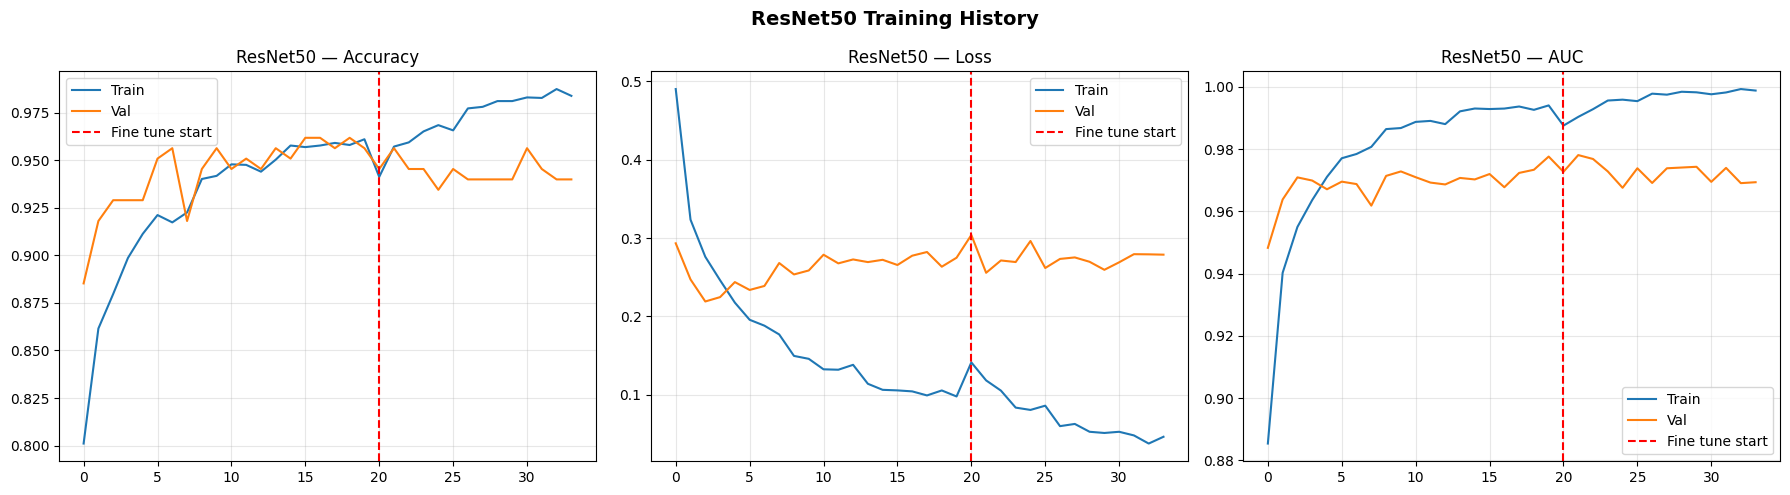

In [ ]:
def plot_history(h1, h2, model_name):
    acc      = h1.history['accuracy']     + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss     = h1.history['loss']         + h2.history['loss']
    val_loss = h1.history['val_loss']     + h2.history['val_loss']
    auc      = h1.history['auc']          + h2.history['auc']
    val_auc  = h1.history['val_auc']      + h2.history['val_auc']
    split    = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, tr, vl, title in zip(
        axes,
        [acc,     loss,     auc],
        [val_acc, val_loss, val_auc],
        ['Accuracy', 'Loss', 'AUC']
    ):
        ax.plot(tr, label='Train')
        ax.plot(vl, label='Val')
        ax.axvline(x=split, color='r',
                   linestyle='--', label='Fine tune start')
        ax.set_title(f'{model_name} — {title}', fontsize=12)
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle(f'{model_name} Training History',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{model_name}_history.png', dpi=150)
    plt.show()

plot_history(history1, history2, MODEL_SAVE_NAME)

In [ ]:
# ── Preprocess Test Set ────────────────────────────
from tensorflow.keras.applications.resnet50 import preprocess_input as r50_preprocess

print("Preprocessing test images...")
X_test, y_test, test_paths = [], [], []

for _, row in tqdm(df_test.iterrows(), total=len(df_test)):
    img = preprocess_image(row['filename'],
                           preprocess_fn=r50_preprocess if USE_PRETRAINED_RESNET50
                                         else resnet_preprocess)
    if img is not None:
        X_test.append(img)
        y_test.append(1 if row['label'] == 'cancer' else 0)
        test_paths.append(row['filename'])

X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"✅ Test shape   : {X_test.shape}")
print(f"Cancer          : {sum(y_test==1)}")
print(f"Non-Cancer      : {sum(y_test==0)}")

Preprocessing test images...


100%|██████████| 131/131 [00:05<00:00, 25.70it/s]


✅ Test shape   : (131, 224, 224, 3)
Cancer          : 87
Non-Cancer      : 44


5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step

AUC Score         : 0.9079
Optimal Threshold : 0.8422

── Default Threshold (0.50) ──
              precision    recall  f1-score   support

  Non-Cancer       0.87      0.77      0.82        44
      Cancer       0.89      0.94      0.92        87

    accuracy                           0.89       131
   macro avg       0.88      0.86      0.87       131
weighted avg       0.88      0.89      0.88       131


── Optimal Threshold (0.84) ──
              precision    recall  f1-score   support

  Non-Cancer       0.86      0.84      0.85        44
      Cancer       0.92      0.93      0.93        87

    accuracy                           0.90       131
   macro avg       0.89      0.89      0.89       131
weighted avg       0.90      0.90      0.90       131



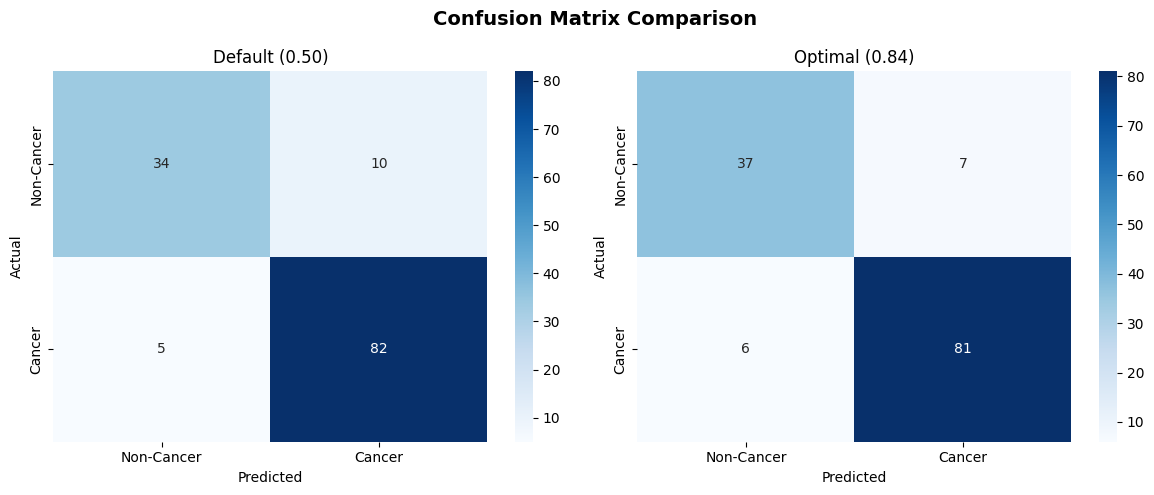

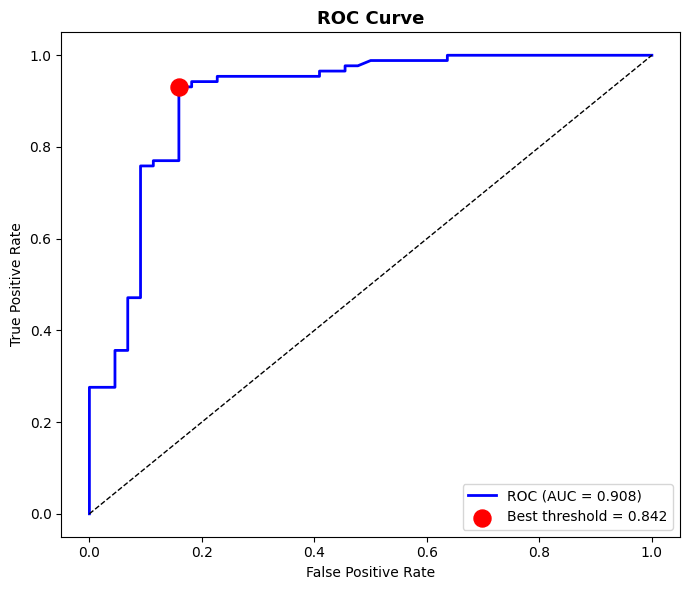

In [ ]:
# ── Load Best Model & Evaluate on Test Set ─────────
resnet_model = tf.keras.models.load_model(
    f'best_{MODEL_SAVE_NAME}.keras',
    custom_objects={'CombinedMetricCallback': CombinedMetricCallback}
)

y_pred_prob = resnet_model.predict(X_test, verbose=1).flatten()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)
best_idx    = np.argmax(tpr - fpr)
best_thresh = thresholds[best_idx]

y_pred_default = (y_pred_prob >= 0.50).astype(int)
y_pred_optimal = (y_pred_prob >= best_thresh).astype(int)

print(f"\nAUC Score         : {auc_score:.4f}")
print(f"Optimal Threshold : {best_thresh:.4f}")

for preds, label in [
    (y_pred_default, 'Default Threshold (0.50)'),
    (y_pred_optimal, f'Optimal Threshold ({best_thresh:.2f})')
]:
    print(f"\n── {label} ──")
    print(classification_report(y_test, preds,
          target_names=['Non-Cancer', 'Cancer']))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(
    axes,
    [y_pred_default, y_pred_optimal],
    ['Default (0.50)', f'Optimal ({best_thresh:.2f})']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Cancer', 'Cancer'],
                yticklabels=['Non-Cancer', 'Cancer'])
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrix Comparison',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC (AUC = {auc_score:.3f})')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red',
            s=150, zorder=5,
            label=f'Best threshold = {best_thresh:.3f}')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Val Set CSV Export ─────────────────────────────
all_paths_recon, all_labels_recon = [], []

for label in ['cancer', 'non_cancer']:
    folder = f'{PREPROCESS_DIR}/{label}'
    for fname in os.listdir(folder):
        all_paths_recon.append(os.path.join(folder, fname))
        all_labels_recon.append(1 if label == 'cancer' else 0)

_, val_paths_r, _, y_val_r = train_test_split(
    all_paths_recon, all_labels_recon,
    test_size=0.2, random_state=42,
    stratify=all_labels_recon
)

preprocess_fn_final = (r50_preprocess if USE_PRETRAINED_RESNET50
                       else resnet_preprocess)

print("Loading val set for CSV export...")
X_val_f, y_val_f, val_paths_f = [], [], []

for fpath, label_int in tqdm(zip(val_paths_r, y_val_r), total=len(val_paths_r)):
    img = cv2.imread(fpath)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32')
    img = preprocess_fn_final(img)
    X_val_f.append(img)
    y_val_f.append(label_int)
    val_paths_f.append(fpath)

X_val_f = np.array(X_val_f)
y_val_f = np.array(y_val_f)

y_val_prob   = resnet_model.predict(X_val_f, batch_size=BATCH_SIZE, verbose=1).flatten()
fpr_v, tpr_v, thresh_v = roc_curve(y_val_f, y_val_prob)
auc_v        = roc_auc_score(y_val_f, y_val_prob)
thresh_v_best = thresh_v[np.argmax(tpr_v - fpr_v)]

y_pred_def_v = (y_val_prob >= 0.50).astype(int)
y_pred_opt_v = (y_val_prob >= thresh_v_best).astype(int)

print(f"\n✅ Val AUC: {auc_v:.4f} | Optimal threshold: {thresh_v_best:.4f}")

results_df = pd.DataFrame({
    'filepath'         : val_paths_f,
    'filename'         : [os.path.basename(f) for f in val_paths_f],
    'actual'           : ['cancer' if y==1 else 'non_cancer' for y in y_val_f],
    'predicted_default': ['cancer' if y==1 else 'non_cancer' for y in y_pred_def_v],
    'predicted_optimal': ['cancer' if y==1 else 'non_cancer' for y in y_pred_opt_v],
    'cancer_prob'      : np.round(y_val_prob, 4),
    'correct_default'  : y_val_f == y_pred_def_v,
    'correct_optimal'  : y_val_f == y_pred_opt_v,
    'result'           : ['✅ CORRECT' if c else '❌ WRONG'
                          for c in (y_val_f == y_pred_opt_v)]
})

results_df.to_csv(f'/content/{MODEL_SAVE_NAME}_val_predictions.csv', index=False)
print(f"✅ Saved → /content/{MODEL_SAVE_NAME}_val_predictions.csv")

total   = len(results_df)
correct = results_df['correct_optimal'].sum()
wrong   = total - correct
cancer_r    = results_df[results_df['actual'] == 'cancer']
noncancer_r = results_df[results_df['actual'] == 'non_cancer']

print(f"\n{'='*45}")
print(f"      VAL PREDICTION COUNT SUMMARY")
print(f"{'='*45}")
print(f"  Total Images    : {total}")
print(f"  ✅ Correct       : {correct}  ({correct/total*100:.1f}%)")
print(f"  ❌ Wrong         : {wrong}   ({wrong/total*100:.1f}%)")
print(f"  Cancer     total : {len(cancer_r)}")
print(f"    ✅ Correct     : {cancer_r['correct_optimal'].sum()}")
print(f"    ❌ Wrong       : {len(cancer_r) - cancer_r['correct_optimal'].sum()}")
print(f"  Non-Cancer total : {len(noncancer_r)}")
print(f"    ✅ Correct     : {noncancer_r['correct_optimal'].sum()}")
print(f"    ❌ Wrong       : {len(noncancer_r) - noncancer_r['correct_optimal'].sum()}")
print(f"{'='*45}")

Loading val set for CSV export...


100%|██████████| 183/183 [00:00<00:00, 1108.67it/s]


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 469ms/step

✅ Val AUC: 0.9792 | Optimal threshold: 0.5521
✅ Saved → /content/ResNet50_val_predictions.csv

      VAL PREDICTION COUNT SUMMARY
  Total Images    : 183
  ✅ Correct       : 175  (95.6%)
  ❌ Wrong         : 8   (4.4%)
  Cancer     total : 93
    ✅ Correct     : 87
    ❌ Wrong       : 6
  Non-Cancer total : 90
    ✅ Correct     : 88
    ❌ Wrong       : 2


In [ ]:
# ── Val Set CSV Export ─────────────────────────────
all_paths_recon, all_labels_recon = [], []

for label in ['cancer', 'non_cancer']:
    folder = f'{PREPROCESS_DIR}/{label}'
    for fname in os.listdir(folder):
        all_paths_recon.append(os.path.join(folder, fname))
        all_labels_recon.append(1 if label == 'cancer' else 0)

_, val_paths_r, _, y_val_r = train_test_split(
    all_paths_recon, all_labels_recon,
    test_size=0.2, random_state=42,
    stratify=all_labels_recon
)

preprocess_fn_final = (r50_preprocess if USE_PRETRAINED_RESNET50
                       else resnet_preprocess)

print("Loading val set for CSV export...")
X_val_f, y_val_f, val_paths_f = [], [], []

for fpath, label_int in tqdm(zip(val_paths_r, y_val_r), total=len(val_paths_r)):
    img = cv2.imread(fpath)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img.astype('float32')
    img = preprocess_fn_final(img)
    X_val_f.append(img)
    y_val_f.append(label_int)
    val_paths_f.append(fpath)

X_val_f = np.array(X_val_f)
y_val_f = np.array(y_val_f)

y_val_prob   = resnet_model.predict(X_val_f, batch_size=BATCH_SIZE, verbose=1).flatten()
fpr_v, tpr_v, thresh_v = roc_curve(y_val_f, y_val_prob)
auc_v        = roc_auc_score(y_val_f, y_val_prob)
thresh_v_best = thresh_v[np.argmax(tpr_v - fpr_v)]

y_pred_def_v = (y_val_prob >= 0.50).astype(int)
y_pred_opt_v = (y_val_prob >= thresh_v_best).astype(int)

print(f"\n✅ Val AUC: {auc_v:.4f} | Optimal threshold: {thresh_v_best:.4f}")

results_df = pd.DataFrame({
    'filepath'         : val_paths_f,
    'filename'         : [os.path.basename(f) for f in val_paths_f],
    'actual'           : ['cancer' if y==1 else 'non_cancer' for y in y_val_f],
    'predicted_default': ['cancer' if y==1 else 'non_cancer' for y in y_pred_def_v],
    'predicted_optimal': ['cancer' if y==1 else 'non_cancer' for y in y_pred_opt_v],
    'cancer_prob'      : np.round(y_val_prob, 4),
    'correct_default'  : y_val_f == y_pred_def_v,
    'correct_optimal'  : y_val_f == y_pred_opt_v,
    'result'           : ['✅ CORRECT' if c else '❌ WRONG'
                          for c in (y_val_f == y_pred_opt_v)]
})

results_df.to_csv(f'/content/{MODEL_SAVE_NAME}_val_predictions.csv', index=False)
print(f"✅ Saved → /content/{MODEL_SAVE_NAME}_val_predictions.csv")

total   = len(results_df)
correct = results_df['correct_optimal'].sum()
wrong   = total - correct
cancer_r    = results_df[results_df['actual'] == 'cancer']
noncancer_r = results_df[results_df['actual'] == 'non_cancer']

print(f"\n{'='*45}")
print(f"      VAL PREDICTION COUNT SUMMARY")
print(f"{'='*45}")
print(f"  Total Images    : {total}")
print(f"  ✅ Correct       : {correct}  ({correct/total*100:.1f}%)")
print(f"  ❌ Wrong         : {wrong}   ({wrong/total*100:.1f}%)")
print(f"  Cancer     total : {len(cancer_r)}")
print(f"    ✅ Correct     : {cancer_r['correct_optimal'].sum()}")
print(f"    ❌ Wrong       : {len(cancer_r) - cancer_r['correct_optimal'].sum()}")
print(f"  Non-Cancer total : {len(noncancer_r)}")
print(f"    ✅ Correct     : {noncancer_r['correct_optimal'].sum()}")
print(f"    ❌ Wrong       : {len(noncancer_r) - noncancer_r['correct_optimal'].sum()}")
print(f"{'='*45}")

Loading val set for CSV export...


100%|██████████| 183/183 [00:00<00:00, 741.69it/s]


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step

✅ Val AUC: 0.9792 | Optimal threshold: 0.5521
✅ Saved → /content/ResNet50_val_predictions.csv

      VAL PREDICTION COUNT SUMMARY
  Total Images    : 183
  ✅ Correct       : 175  (95.6%)
  ❌ Wrong         : 8   (4.4%)
  Cancer     total : 93
    ✅ Correct     : 87
    ❌ Wrong       : 6
  Non-Cancer total : 90
    ✅ Correct     : 88
    ❌ Wrong       : 2
